<a href="https://colab.research.google.com/github/amannayanmujawar/Breast-Cancer-Diagnosis-Prediction-using-Decision-Tree-/blob/main/Breast_Cancer_Dignosis_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Test case :- from the given data wbc.csv we need to predict the presence of cancer. or not

information about the data ?


this csv file conatins test reports on different ehite blood cells based on that tets we need to pedcit cancer is present or not

so b uild a ML model to predict the cancer

* Import ncessary libraries

In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

* Load The Dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/wbc.csv")

**EDA**

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# shape of the data
rows,columns = df.shape
print(f"No of {rows} rows and  {columns} columns")

No of 569 rows and  32 columns


In [5]:
df.dtypes

,0
id,int64
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64


In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
# columns
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

* From the above command i can see columns are unrelated columns
1. id -->  we are nothing  to do with patient id means wont apply any arthmetic so i am dropping the column  


In [8]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# drop the unreleated columns
df.drop(columns=['id'],inplace=True)

* Target varibale in this data --> Dignosis is target variable
* it is classification varibale
* we need to predict categorical
* df['dignosis'] --> M--> malignant and B--> Benign

In [11]:
df['diagnosis'].unique()
# There is 2 category it is binary classification
# we need predict -->   M--> malignant and B--> Benign

array(['M', 'B'], dtype=object)

In [12]:
# check the distribution of value in the dignosis
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [13]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


* Define Features and Target

In [14]:
X = df.loc[:,df.columns[1:]]
y = df['diagnosis']

In [15]:
# in the column dignosis M and B are categorical convert in to numbers
# replace M ---> 1 and B ---> 0
# to replace we use the map() function
y = y.map({'M':1,'B':0})

In [16]:
y.head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


* split the data in tom training and testing

In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=7)

* Scale the data

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
from sklearn.tree import DecisionTreeClassifier
# initialize the model
treemodel = DecisionTreeClassifier()
# fit the training data
treemodel.fit(X_train,y_train)  # loss automatically calculated --> reduction in entropy
# prediction on the test data
y_pred = treemodel.predict(X_test)
y_pred

array([0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

* Model Evaluation

In [71]:
from sklearn.metrics import accuracy_score,f1_score
acc = accuracy_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)
print(acc)
print(f1_score)

0.9300699300699301
0.8888888888888888


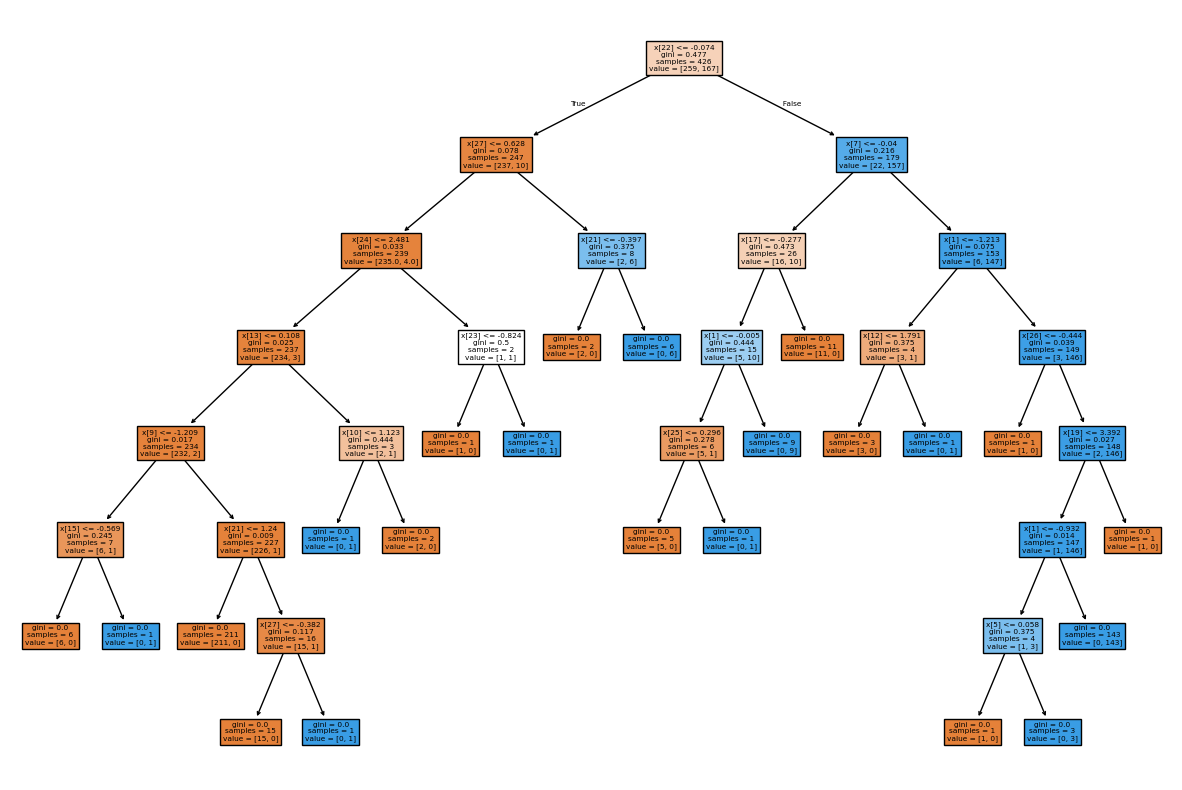

In [72]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(treemodel,filled=True)
plt.show()

* We need to find maximum depth by using hit and trail method

In [73]:
from sklearn.model_selection import cross_val_score
for depth in [1,2,3,4,5,6,7,8,9,10,20,30]:
  dt = DecisionTreeClassifier(max_depth=depth)
  dt.fit(X_train,y_train)
  train_accuracy = dt.score(X_train,y_train)
  val_accuracy = cross_val_score(dt,X_train,y_train,cv=10)
  print("Depth:",depth,"Training accuracy:",train_accuracy,"cross_val_score:",np.mean(val_accuracy))

Depth: 1 Training accuracy: 0.9248826291079812 cross_val_score: 0.9061461794019934
Depth: 2 Training accuracy: 0.9483568075117371 cross_val_score: 0.9227021040974529
Depth: 3 Training accuracy: 0.9694835680751174 cross_val_score: 0.9247508305647841
Depth: 4 Training accuracy: 0.9859154929577465 cross_val_score: 0.9223698781838318
Depth: 5 Training accuracy: 0.9929577464788732 cross_val_score: 0.9293466223698783
Depth: 6 Training accuracy: 0.9953051643192489 cross_val_score: 0.9248062015503876
Depth: 7 Training accuracy: 1.0 cross_val_score: 0.9224806201550388
Depth: 8 Training accuracy: 1.0 cross_val_score: 0.9245847176079736
Depth: 9 Training accuracy: 1.0 cross_val_score: 0.9199889258028794
Depth: 10 Training accuracy: 1.0 cross_val_score: 0.9341638981173865
Depth: 20 Training accuracy: 1.0 cross_val_score: 0.9245847176079736
Depth: 30 Training accuracy: 1.0 cross_val_score: 0.9152270210409746


* The maximum depth i ll be getting is 5

- again train the model by using max depth
- also i will helps to reduce overfitting

In [74]:
from sklearn.tree import DecisionTreeClassifier
# initialize the model and fit training data
dt =  DecisionTreeClassifier(max_depth=5)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [75]:
# predict on the test data
dt_pred = dt.predict(X_test)
dt_pred

array([0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [76]:
# evaluate the model
from sklearn.metrics import accuracy_score,f1_score
acc = accuracy_score(y_test,dt_pred)
f1_score = f1_score(y_test,dt_pred)
print(acc)
print(f1_score)

0.9230769230769231
0.8735632183908046


* feature importance

In [77]:
df.shape

(569, 31)

In [78]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=7)

In [80]:
from sklearn.tree import DecisionTreeClassifier
#initialize the model
dt = DecisionTreeClassifier(criterion="gini",max_depth=5)
dt.fit(x_train,y_train)
importance = dt.feature_importances_
list(zip(importance,x_test.columns))

[(np.float64(0.0), 'radius_mean'),
 (np.float64(0.046359823061412425), 'texture_mean'),
 (np.float64(0.0), 'perimeter_mean'),
 (np.float64(0.0), 'area_mean'),
 (np.float64(0.0), 'smoothness_mean'),
 (np.float64(0.016044002477090553), 'compactness_mean'),
 (np.float64(0.0), 'concavity_mean'),
 (np.float64(0.0747569857936474), 'concave points_mean'),
 (np.float64(0.0), 'symmetry_mean'),
 (np.float64(0.0013190035744923404), 'fractal_dimension_mean'),
 (np.float64(0.0), 'radius_se'),
 (np.float64(0.0), 'texture_se'),
 (np.float64(0.0), 'perimeter_se'),
 (np.float64(0.003166099807228499), 'area_se'),
 (np.float64(0.0), 'smoothness_se'),
 (np.float64(0.0), 'compactness_se'),
 (np.float64(0.0), 'concavity_se'),
 (np.float64(0.028580409270930533), 'concave points_se'),
 (np.float64(0.0), 'symmetry_se'),
 (np.float64(0.009928120207903785), 'fractal_dimension_se'),
 (np.float64(0.0), 'radius_worst'),
 (np.float64(0.02026610839211438), 'texture_worst'),
 (np.float64(0.7360816016865359), 'perimete

[Text(0.5336538461538461, 0.9166666666666666, 'perimeter_worst <= 106.1\ngini = 0.477\nsamples = 426\nvalue = [259, 167]\nclass = y[0]'),
 Text(0.3557692307692308, 0.75, 'concave points_worst <= 0.159\ngini = 0.078\nsamples = 247\nvalue = [237, 10]\nclass = y[0]'),
 Text(0.44471153846153844, 0.8333333333333333, 'True  '),
 Text(0.25, 0.5833333333333334, 'smoothness_worst <= 0.191\ngini = 0.033\nsamples = 239\nvalue = [235.0, 4.0]\nclass = y[0]'),
 Text(0.15384615384615385, 0.4166666666666667, 'area_se <= 47.035\ngini = 0.025\nsamples = 237\nvalue = [234, 3]\nclass = y[0]'),
 Text(0.07692307692307693, 0.25, 'fractal_dimension_mean <= 0.054\ngini = 0.017\nsamples = 234\nvalue = [232, 2]\nclass = y[0]'),
 Text(0.038461538461538464, 0.08333333333333333, 'gini = 0.245\nsamples = 7\nvalue = [6, 1]\nclass = y[0]'),
 Text(0.11538461538461539, 0.08333333333333333, 'gini = 0.009\nsamples = 227\nvalue = [226, 1]\nclass = y[0]'),
 Text(0.23076923076923078, 0.25, 'fractal_dimension_worst <= 0.079\n

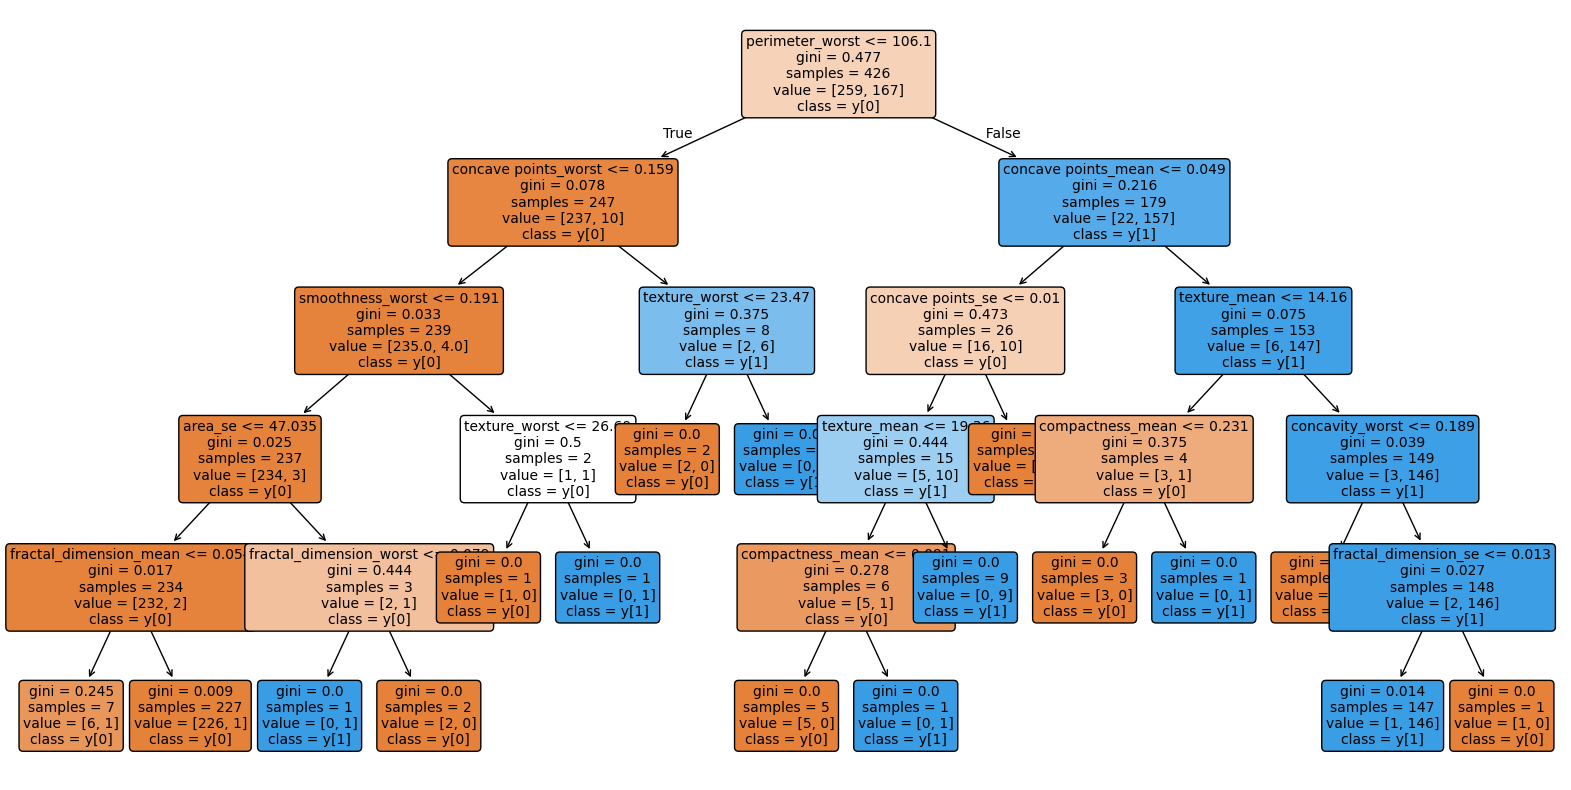

In [82]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt,filled=True,rounded=True,feature_names=x_train.columns,class_names=True,fontsize=10)
# gini measure the randomness